In [16]:
from prepare_output_file import collect_json_files
from utils import load_json, save_json, dialogue_to_string, extract_dialogue
from tqdm import tqdm
import dotenv

In [17]:
dev_predictions = collect_json_files("experiment_6/output_dev/")
dev_truth = load_json("data/source/mrbench_v3_devset.json")

In [18]:
dev_predictions_ids = [i['conversation_id'] for i in dev_predictions]

In [19]:
target_ids = dev_predictions_ids[0]

yh = [p for p in dev_predictions if p['conversation_id'] == target_ids][0]
y = [truth for truth in dev_truth if truth['conversation_id'] == target_ids][0]

print(target_ids)

429348089


In [20]:
dialogue = dialogue_to_string(extract_dialogue(y["conversation_history"]))
print(dialogue)

- Tutor: What is the value of 2800 subtracted by 65?
- Tutor: 2800-65=?
- Tutor: Are you there?
- Student: 1745


In [21]:
for tutor in y['tutor_responses']:
    response = y['tutor_responses'][tutor]['response']
    value = y['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    predicted = yh['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    print(f"--- {tutor} ---")
    print(f"response: {response}")
    print(f"Truth: {value}")
    print(f"Predicted: {predicted}")

    

--- Expert ---
response: Great try! Let's check our answer. How can we check our answer?
Truth: To some extent
Predicted: Yes
--- Novice ---
response: Nice effort! I can see from your approach that you really understand the concept here. There is just one piece we need to look at again.
Truth: To some extent
Predicted: To some extent
--- Llama318B ---
response: I can see you've tried your best, but let's take a closer look at the problem - when we subtract 65 from 2800, we need to make sure we're borrowing correctly from the hundreds place to the tens place, so let's go through it step by step together.
Truth: Yes
Predicted: Yes
--- Phi3 ---
response: Great effort! But remember to double-check your subtraction. Try using vertical calculation for more accuracy: 2800 - 65 equals?
Truth: Yes
Predicted: Yes
--- Sonnet ---
response: That's a good attempt, but let's review the subtraction process together to find the correct answer.
Truth: Yes
Predicted: Yes
--- Llama31405B ---
response: I c

In [28]:
def evaluate_mistake_identification_f1_multiclass(gold_data, pred_data, mode='strict', average="macro"):
    y_true = []
    y_pred = []
    tutors = []
    instances = []

    label_mapping = {
        "yes": 0,
        "to some extent": 1,
        "no": 2
    }

    inverse_label_mapping = {v: k for k, v in label_mapping.items()}

    if mode != 'strict':
        label_mapping = {
        "yes": 0,
        "to some extent": 0,
        "no":1
        }


    pred_lookup = {item['conversation_id']: item for item in pred_data}

    for gold_item in gold_data:
        conv_id = gold_item['conversation_id']
        if conv_id not in pred_lookup:
            continue

        pred_item = pred_lookup[conv_id]

        for model_name, gold_response in gold_item['tutor_responses'].items():
            if model_name not in pred_item['tutor_responses']:
                continue

            pred_response = pred_item['tutor_responses'][model_name]

            gold_label = gold_response['annotation']['Mistake_Identification'].strip().lower()
            pred_label = pred_response['annotation']['Mistake_Identification'].strip().lower()

            if gold_label in label_mapping and pred_label in label_mapping:
                y_true.append(label_mapping[gold_label])
                y_pred.append(label_mapping[pred_label])
                tutors.append(model_name)
                instances.append({
                    'conversation_id': conv_id,
                    'model_name': model_name,
                    'gold_label': gold_label,
                    'pred_label': pred_label
                })

    if not y_true:
        print("No matching predictions found.")
        return 0.0
    return y_true, y_pred, tutors, instances

y_true, y_pred, tutors, instances = evaluate_mistake_identification_f1_multiclass(dev_truth, dev_predictions, average="macro")

In [29]:
label_mapping = {
    "yes": 0,
    "to some extent": 1,
    "no": 2
}

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

tutors_evaluated = {}
filtered_instances = []

c = 0

for i,j,k in zip(y_true, y_pred, tutors):
    if inverse_label_mapping[i] != inverse_label_mapping[j]:
        filtered_instances.append({
            'conversation_id': instances[c]['conversation_id'],
            'model_name': instances[c]['model_name'],
            'gold_label': inverse_label_mapping[i],
            'pred_label': inverse_label_mapping[j]
        })
        if k not in tutors_evaluated:
            tutors_evaluated[k] = [(inverse_label_mapping[i], inverse_label_mapping[j])]
        else:
            tutors_evaluated[k].append((inverse_label_mapping[i], inverse_label_mapping[j]))
    c += 1

In [30]:
tutors_evaluated

{'Sonnet': [('yes', 'no'),
  ('to some extent', 'yes'),
  ('no', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('no', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('no', 'yes')],
 'Llama318B': [('yes', 'to some extent'),
  ('yes', 'no'),
  ('no', 'yes'),
  ('no', 'to some extent'),
  ('yes', 'no'),
  ('yes', 'to some extent'),
  ('yes', 'no'),
  ('no', 'yes'),
  ('no', 'to some extent')],
 'Novice': [('yes', 'no'),
  ('yes', 'to some extent'),
  ('to some extent', 'yes'),
  ('to some extent', 'no'),
  ('yes', 'to some extent'),
  ('to some extent', 'no'),
  ('yes', 'to some extent'),
  ('to some extent', 'no'),
  ('yes', 'no'),
  ('to some extent', 'no')],
 'Mistral': [('yes', 'to some extent'),
  ('to some extent', 'no'),
  ('no', 'yes'),
  ('yes', 'to some extent'),
  ('to some extent', 'yes'),
  ('to some extent', 'yes')],
 'Expert': [('yes', 'to some extent'),
  ('yes', 'no'),
  ('yes', 

In [32]:
# sort the instances by conversation_id
filtered_instances.sort(key=lambda x: x['conversation_id'])
filtered_instances

[{'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'no'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'no'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'no'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Llama31405B',
  'gold_label': 'no',
  'pred_label': 'yes'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '221-362eb11a-f190-42a6-b2a4-985fafdcfa9e',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},


In [25]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def print_classification_report(y_true, y_pred):
    # Convert the lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Print the classification report
    print(classification_report(y_true, y_pred, target_names=list(label_mapping.keys())))

# Print the classification report
print_classification_report(y_true, y_pred)

                precision    recall  f1-score   support

           yes       0.93      0.91      0.92       332
to some extent       0.30      0.43      0.35        30
            no       0.69      0.64      0.66        55

      accuracy                           0.84       417
     macro avg       0.64      0.66      0.64       417
  weighted avg       0.86      0.84      0.85       417



Confusion Matrix:


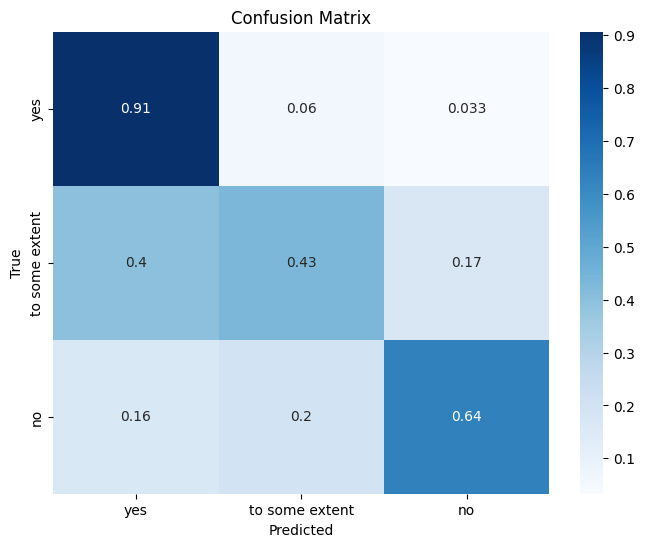

In [26]:
# plot cm matric

import matplotlib.pyplot as plt
import seaborn as sns

# Print the confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
print("Confusion Matrix:")


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, list(label_mapping.keys()))

In [27]:
cm

array([[0.90662651, 0.06024096, 0.03313253],
       [0.4       , 0.43333333, 0.16666667],
       [0.16363636, 0.2       , 0.63636364]])